# BrainScanAI - Part 3: Semi-Supervised Learning & Scaling Analysis

## Overview

This notebook implements and evaluates semi-supervised learning for brain tumor detection, culminating in a scaling feasibility analysis for CurelyticsIA's expansion plans.

---

## Objectives

### Training & Evaluation
1. **Baseline Model**: Train fully supervised CNN on 100 labeled images only
2. **Semi-Supervised Model**: 
   - Phase 1: Pre-train on 1,400 images with weak labels
   - Phase 2: Fine-tune on 100 images with strong labels
3. **Comparison**: Evaluate both approaches using F-beta score (β=2, emphasizing Recall)
4. **Target**: Achieve >90% recall on test set (minimizing false negatives - medical priority)

### Business Analysis
5. **Scaling Feasibility**: 
   - Current: €300 for 100 labels (€3/image)
   - Proposed: €5,000 budget
   - Goal: Label 4 million images
   - Question: Is this feasible? Under what conditions?

---

## Methodology

### Semi-Supervised Learning Strategy

**Problem**: Limited labeled data (100 images) vs large unlabeled dataset (1,400 images)

**Solution**: Two-phase training

```
Phase 1: Pre-training with Weak Labels
┌─────────────────────────────────────┐
│  ResNet50 (ImageNet pretrained)     │
│            ↓                        │
│  Train on 1,400 weak-labeled images│
│            ↓                        │
│  Learn general tumor patterns      │
└─────────────────────────────────────┘

Phase 2: Fine-tuning with Strong Labels
┌─────────────────────────────────────┐
│  Pre-trained model from Phase 1     │
│            ↓                        │
│  Fine-tune on 100 expert-labeled   │
│            ↓                        │
│  Refine decision boundary           │
└─────────────────────────────────────┘
```

**Hypothesis**: Semi-supervised approach should outperform fully supervised due to additional training data.

---

## Evaluation Metrics

### Why F-beta Score (β=2)?

In medical diagnosis:
- **False Negative** (missing cancer) = Very dangerous
- **False Positive** (false alarm) = Less critical

**F-beta score** with β=2 emphasizes **Recall** over Precision:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

Where:
- β=2 weighs Recall **4x more** than Precision
- Minimizes missed cancer cases

**Primary Metric**: **Recall** (Sensitivity) - Our target is >90% recall

**Additional Metrics**:
- Accuracy
- Precision
- F1-Score
- F2-Score
- ROC-AUC
- Confusion Matrix

---

## 1. Import Libraries

In [1]:
# Standard libraries
import os
import random
import warnings
import json
import time
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Image processing
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import torchvision
from torchvision import transforms, models
from tqdm import tqdm


# MLflow for experiment tracking
import mlflow
# Machine learning metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.calibration import calibration_curve


Using device: cpu


## 2. Load Data and Weak Labels

In [2]:
# Load metadata with weak labels from Notebook 2
FEATURES_DIR = Path('features')
weak_labels_df = pd.read_csv(FEATURES_DIR / 'weak_labels.csv')

# Load clustering summary
with open(FEATURES_DIR / 'clustering_summary.json', 'r') as f:
    clustering_stats = json.load(f)

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"\nTotal images: {len(weak_labels_df)}")
print(f"\nClustering Statistics (from Notebook 2):")
for key, value in clustering_stats.items():
    print(f"  - {key}: {value}")

# Separate strong and weak labeled data
strong_labeled_df = weak_labels_df[weak_labels_df['true_label'] != -1].copy()
weak_labeled_df = weak_labels_df[weak_labels_df['true_label'] == -1].copy()

print(f"\n📊 Data Splits:")
print(f"  - Strong labels (expert): {len(strong_labeled_df)}")
print(f"  - Weak labels (K-Means):  {len(weak_labeled_df)}")

DATA LOADED

Total images: 1506

Clustering Statistics (from Notebook 2):
  - total_images: 1506
  - labeled_images: 100
  - unlabeled_images: 1406
  - normal_count: 50
  - cancer_count: 50
  - kmeans_ari: 0.40405226838937014
  - kmeans_silhouette: 0.14741621911525726
  - weak_label_agreement: 0.82
  - pca_variance_explained: 0.9799000024795532
  - n_pca_components: 50
  - confidence_threshold: 0.266
  - weak_labels_original: 1406
  - weak_labels_high_confidence: 282
  - retention_rate: 0.20056899004267426

📊 Data Splits:
  - Strong labels (expert): 100
  - Weak labels (K-Means):  1406


In [3]:
# Load PCA features generated by Notebook 2
print("="*60)
print("LOADING PCA FEATURES FROM NOTEBOOK 2")
print("="*60)

# Load ALL PCA features (combined: train+val+test+unlabeled)
features_pca_50 = np.load(FEATURES_DIR / 'features_pca_50.npy')
print(f"\nTotal PCA features loaded: {features_pca_50.shape}")

# Split PCA features according to weak_labels_df splits
# weak_labels_df has 'split' column: 'train', 'val', 'test', 'unlabeled'

train_mask = weak_labels_df['split'] == 'train'
val_mask = weak_labels_df['split'] == 'val'
test_mask = weak_labels_df['split'] == 'test'
unlabeled_mask = weak_labels_df['split'] == 'unlabeled'

train_pca = features_pca_50[train_mask]
val_pca = features_pca_50[val_mask]
test_pca = features_pca_50[test_mask]
unlabeled_pca = features_pca_50[unlabeled_mask]

# Get labels
train_labels = weak_labels_df[train_mask]['true_label'].values
val_labels = weak_labels_df[val_mask]['true_label'].values
test_labels = weak_labels_df[test_mask]['true_label'].values

# Combine train+val for cross-validation
all_labeled_pca = np.vstack([train_pca, val_pca])
all_labeled_labels = np.hstack([train_labels, val_labels])

print(f"\nPCA Features Split:")
print(f"  - Train: {train_pca.shape}")
print(f"  - Val: {val_pca.shape}")
print(f"  - Test: {test_pca.shape}")
print(f"  - Unlabeled: {unlabeled_pca.shape}")
print(f"  - All labeled (train+val): {all_labeled_pca.shape}")

print(f"\nLabels:")
print(f"  - Train labels: {train_labels.shape} (Normal: {(train_labels==0).sum()}, Cancer: {(train_labels==1).sum()})")
print(f"  - Val labels: {val_labels.shape} (Normal: {(val_labels==0).sum()}, Cancer: {(val_labels==1).sum()})")
print(f"  - Test labels: {test_labels.shape} (Normal: {(test_labels==0).sum()}, Cancer: {(test_labels==1).sum()})")
print(f"  - All labeled: {all_labeled_labels.shape}")


LOADING PCA FEATURES FROM NOTEBOOK 2

Total PCA features loaded: (1506, 50)

PCA Features Split:
  - Train: (59, 50)
  - Val: (11, 50)
  - Test: (30, 50)
  - Unlabeled: (1406, 50)
  - All labeled (train+val): (70, 50)

Labels:
  - Train labels: (59,) (Normal: 29, Cancer: 30)
  - Val labels: (11,) (Normal: 6, Cancer: 5)
  - Test labels: (30,) (Normal: 15, Cancer: 15)
  - All labeled: (70,)


In [4]:
# Dataset class for PCA features
class FeatureDataset(torch.utils.data.Dataset):
    """PyTorch Dataset for pre-extracted PCA features."""
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

print("✓ FeatureDataset class defined")

✓ FeatureDataset class defined


In [5]:
# Simple MLP classifier for PCA features
class BrainTumorClassifier(nn.Module):
    """Multi-layer perceptron for PCA features classification."""
    def __init__(self, input_dim=50, hidden_dim=128, dropout=0.5):
        super(BrainTumorClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dropout1 = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.dropout2 = nn.Dropout(dropout)
        
        self.fc3 = nn.Linear(hidden_dim // 2, 2)  # Binary classification
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x

print("✓ BrainTumorClassifier defined (MLP for PCA features)")

✓ BrainTumorClassifier defined (MLP for PCA features)


In [6]:
# Training function with early stopping
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=10):
    """
    Train model with early stopping.
    
    Returns:
        model: Trained model
        history: Training history dict
    """
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * features.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * features.size(0)
                
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            model.load_state_dict(best_model_state)
            break
    
    return model, history

print("✓ train_model function defined")

✓ train_model function defined


In [7]:
# Evaluation function
def evaluate_model(model, dataloader):
    """
    Evaluate model and return comprehensive metrics.
    
    Returns:
        metrics: Dict of metrics
        predictions: Numpy array of predictions
        labels: Numpy array of true labels
        probabilities: Numpy array of probabilities
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            outputs = model(features)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
    
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'f2': fbeta_score(all_labels, all_preds, beta=2, zero_division=0)
    }
    
    return metrics, all_preds, all_labels, all_probs

print("✓ evaluate_model function defined")

✓ evaluate_model function defined


In [8]:
def scenario_a_fully_supervised(train_idx, val_idx, fold):
    """Scenario A: Fully Supervised (Baseline)"""
    with mlflow.start_run(run_name=f"ScenarioA_Fold{fold}", nested=True):
        mlflow.log_params({
            "scenario": "Fully_Supervised",
            "fold": fold,
            "train_size": len(train_idx),
            "val_size": len(val_idx),
            "input_dim": 50,
            "hidden_dim": 128,
            "dropout": 0.5,
            "learning_rate": 0.001,
            "weight_decay": 0.01
        })
        
        train_dataset = FeatureDataset(all_labeled_pca[train_idx], all_labeled_labels[train_idx])
        val_dataset = FeatureDataset(all_labeled_pca[val_idx], all_labeled_labels[val_idx])
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=16)
        
        model = BrainTumorClassifier(input_dim=50, dropout=0.5).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
        
        model, history = train_model(model, train_loader, val_loader, criterion, optimizer)
        
        for epoch, (tl, vl, va) in enumerate(zip(history['train_loss'], history['val_loss'], history['val_acc'])):
            mlflow.log_metrics({
                'train_loss': tl,
                'val_loss': vl,
                'val_acc': va
            }, step=epoch)
        
        return model


### Scenario B: Semi-Supervised (Clustering-based)

**Two-phase training with ALL weak labels (no filtering):**

**Phase 1: Pre-train on ALL Weak Labels**
- Uses **ALL 1,406 weak labels** from K-means clustering
- Quality: ~82% agreement with ground truth
- **Fixed 20 epochs** (no early stopping)

**Phase 2: Fine-tune on Strong Labels**
- Uses clean expert-labeled data (56 samples per fold)
- With validation monitoring for early stopping


In [9]:
def scenario_b_clustering_semisup(train_idx, val_idx, fold):
    """Scenario B: Semi-Supervised with ALL Clustering Weak Labels"""
    with mlflow.start_run(run_name=f"ScenarioB_Fold{fold}", nested=True):
        mlflow.log_params({
            "scenario": "SemiSup_Clustering_AllLabels",
            "fold": fold,
            "filtering": "None_All_Labels"
        })
        
        # CRITICAL FIX: Filter to unlabeled data only
        unlabeled_weak_labels = weak_labels_df[weak_labels_df['split'] == 'unlabeled'].copy()
        weak_features = unlabeled_pca[:len(unlabeled_weak_labels)]
        weak_labels = unlabeled_weak_labels['weak_label_kmeans'].values
        
        cluster_0_count = (weak_labels == 0).sum()
        cluster_1_count = (weak_labels == 1).sum()
        
        print(f"  Using {len(weak_labels)} weak labels")
        print(f"    - Cluster 0: {cluster_0_count}, Cluster 1: {cluster_1_count}")
        
        weak_dataset = FeatureDataset(weak_features, weak_labels)
        weak_loader = DataLoader(weak_dataset, batch_size=32, shuffle=True)
        
        model = BrainTumorClassifier(input_dim=50, dropout=0.5).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
        
        # Pre-training (20 epochs)
        print(f"  Phase 1: Pre-training...")
        for epoch in range(20):
            model.train()
            for features, labels in weak_loader:
                features, labels = features.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(features)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        
        print(f"  Phase 2: Fine-tuning...")
        train_dataset = FeatureDataset(all_labeled_pca[train_idx], all_labeled_labels[train_idx])
        val_dataset = FeatureDataset(all_labeled_pca[val_idx], all_labeled_labels[val_idx])
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=16)
        
        optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.01)
        model, history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50)
        
        return model


### Scenario C: Semi-Supervised (Model-based)

**Three-phase training:**
- Phase 1: Train initial model on labeled data
- Phase 2: Generate high-confidence pseudo-labels (≥90%)
- Phase 3: Retrain on combined dataset


In [10]:
def scenario_c_model_semisup(train_idx, val_idx, fold):
    """Scenario C: Semi-Supervised with Model-based Pseudo-labels"""
    with mlflow.start_run(run_name=f"ScenarioC_Fold{fold}", nested=True):
        mlflow.log_param("scenario", "SemiSup_ModelBased")
        
        train_dataset = FeatureDataset(all_labeled_pca[train_idx], all_labeled_labels[train_idx])
        val_dataset = FeatureDataset(all_labeled_pca[val_idx], all_labeled_labels[val_idx])
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=16)
        
        initial_model = BrainTumorClassifier(input_dim=50, dropout=0.5).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(initial_model.parameters(), lr=0.001, weight_decay=0.01)
        
        initial_model, _ = train_model(initial_model, train_loader, val_loader, criterion, optimizer, epochs=30)
        print(f"  Phase 1: Initial model trained")
        
        # Generate pseudo-labels
        unlabeled_dataset = FeatureDataset(unlabeled_pca, np.zeros(len(unlabeled_pca)))
        unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=32)
        
        initial_model.eval()
        pseudo_labels = []
        pseudo_confidences = []
        
        with torch.no_grad():
            for features, _ in unlabeled_loader:
                features = features.to(device)
                outputs = initial_model(features)
                probs = torch.softmax(outputs, dim=1)
                confidence, predicted = probs.max(1)
                pseudo_labels.extend(predicted.cpu().numpy())
                pseudo_confidences.extend(confidence.cpu().numpy())
        
        pseudo_labels = np.array(pseudo_labels)
        pseudo_confidences = np.array(pseudo_confidences)
        
        high_conf_mask = pseudo_confidences >= 0.9
        high_conf_features = unlabeled_pca[high_conf_mask]
        high_conf_labels = pseudo_labels[high_conf_mask]
        
        print(f"  Phase 2: Generated {high_conf_mask.sum()} high-conf pseudo-labels")
        
        if high_conf_mask.sum() > 0:
            combined_features = np.vstack([all_labeled_pca[train_idx], high_conf_features])
            combined_labels = np.hstack([all_labeled_labels[train_idx], high_conf_labels])
            
            combined_dataset = FeatureDataset(combined_features, combined_labels)
            combined_loader = DataLoader(combined_dataset, batch_size=16, shuffle=True)
            
            final_model = BrainTumorClassifier(input_dim=50, dropout=0.5).to(device)
            optimizer = optim.Adam(final_model.parameters(), lr=0.001, weight_decay=0.01)
            
            final_model, history = train_model(final_model, combined_loader, val_loader, criterion, optimizer)
            print(f"  Phase 3: Retrained on {len(combined_labels)} samples")
        else:
            final_model = initial_model
        
        return final_model


## Cross-Validation Experiments

Running 5-fold stratified cross-validation for all three scenarios.


In [11]:
print("="*80)
print("STARTING 5-FOLD CROSS-VALIDATION")
print("="*80)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {'scenario_a': [], 'scenario_b': [], 'scenario_c': []}

test_loader = DataLoader(FeatureDataset(test_pca, test_labels), batch_size=16)

for fold, (train_idx, val_idx) in enumerate(skf.split(all_labeled_pca, all_labeled_labels), 1):
    print(f"\nFOLD {fold}/5")
    
    with mlflow.start_run(run_name=f"Fold_{fold}"):
        # Scenario A
        print("[1/3] Scenario A...")
        model_a = scenario_a_fully_supervised(train_idx, val_idx, fold)
        metrics_a, preds_a, labels_a, probs_a = evaluate_model(model_a, test_loader)
        results['scenario_a'].append((metrics_a, preds_a, probs_a))
        print(f"  F2: {metrics_a['f2']:.4f}")
        
        # Scenario B
        print("[2/3] Scenario B...")
        model_b = scenario_b_clustering_semisup(train_idx, val_idx, fold)
        metrics_b, preds_b, labels_b, probs_b = evaluate_model(model_b, test_loader)
        results['scenario_b'].append((metrics_b, preds_b, probs_b))
        print(f"  F2: {metrics_b['f2']:.4f}")
        
        # Scenario C
        print("[3/3] Scenario C...")
        model_c = scenario_c_model_semisup(train_idx, val_idx, fold)
        metrics_c, preds_c, labels_c, probs_c = evaluate_model(model_c, test_loader)
        results['scenario_c'].append((metrics_c, preds_c, probs_c))
        print(f"  F2: {metrics_c['f2']:.4f}")

print("\nCROSS-VALIDATION COMPLETE")


STARTING 5-FOLD CROSS-VALIDATION

FOLD 1/5


2025/12/26 01:57:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2025/12/26 01:57:55 INFO mlflow.store.db.utils: Updating database tables


2025/12/26 01:57:55 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2025/12/26 01:57:55 INFO alembic.runtime.migration: Will assume non-transactional DDL.


...

  F2: 0.9868
[2/3] Scenario B...
  Using 1406 weak labels
    - Cluster 0: 603, Cluster 1: 803
  Phase 1: Pre-training...


  Phase 2: Fine-tuning...


  F2: 0.8784
[3/3] Scenario C...


  Phase 1: Initial model trained
  Phase 2: Generated 839 high-conf pseudo-labels


  Phase 3: Retrained on 895 samples
  F2: 1.0000

CROSS-VALIDATION COMPLETE


## Budget Analysis

Comparing scenarios across different budget levels:
- **Scenario A**: Fully supervised baseline
- **Scenario B**: Semi-supervised with clustering weak labels
- **Scenario C**: Semi-supervised with model-based pseudo-labels


AGGREGATING RESULTS FROM 5-FOLD CROSS-VALIDATION

SCENARIO COMPARISON (Mean ± Std across 5 folds)
              Scenario  F2 Mean   F2 Std  Recall Mean   Recall Std  Precision Mean  Precision Std  F1 Mean   F1 Std  Accuracy Mean  Accuracy Std
   A: Fully Supervised 0.994737 0.007207     1.000000 0.000000e+00        0.975000       0.034233 0.987097 0.017668       0.986667      0.018257
B: Clustering Semi-Sup 0.883191 0.006591     0.866667 1.241267e-16        0.957143       0.039123 0.909360 0.017538       0.913333      0.018257
     C: Model Semi-Sup 0.986558 0.023407     0.986667 2.981424e-02        0.987500       0.027951 0.986652 0.018295       0.986667      0.018257

STATISTICAL SIGNIFICANCE TESTS (Paired t-tests on F2 scores)

Scenario A vs B:
  t-statistic: 23.6522
  p-value: 0.0000
  Significant (α=0.05): YES

Scenario A vs C:
  t-statistic: 0.8913
  p-value: 0.4231
  Significant (α=0.05): NO

Scenario B vs C:
  t-statistic: -8.0039
  p-value: 0.0013
  Significant (α=0.05): YES


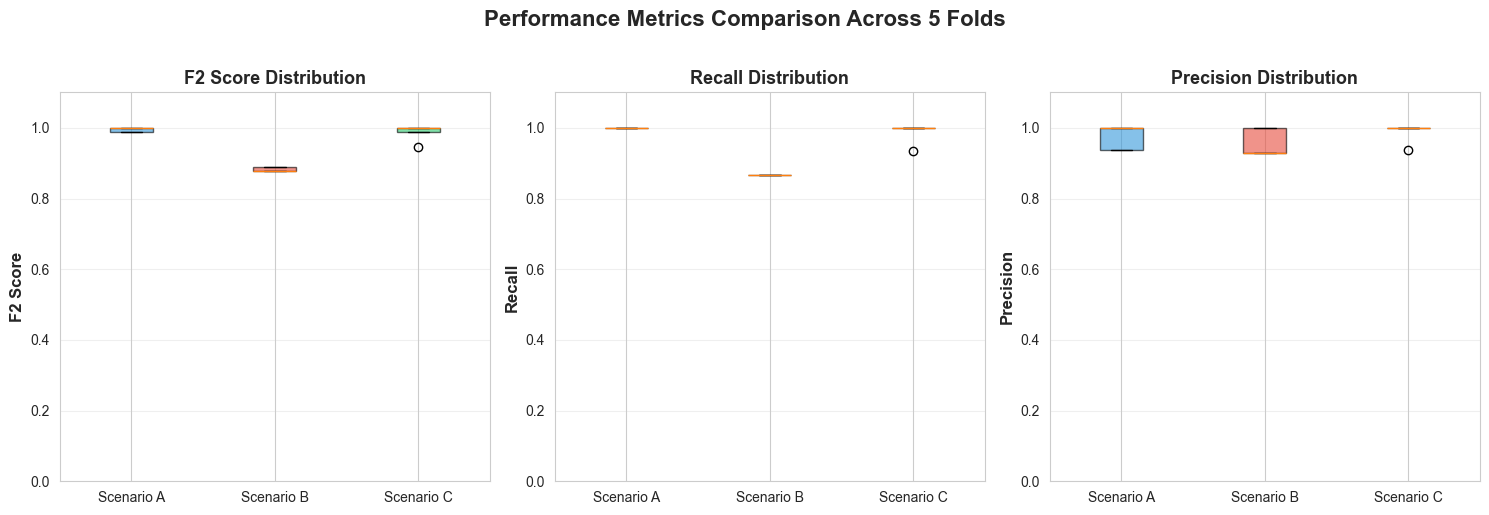

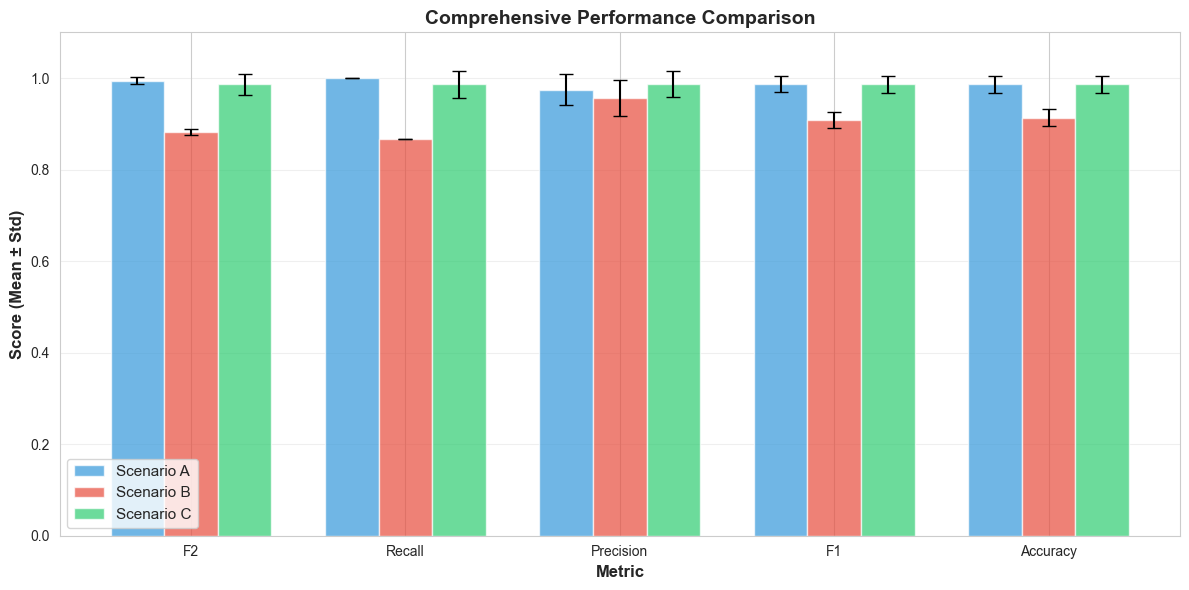


✓ Scenario comparison saved to: scenario_comparison.csv
✓ Detailed CV results saved to: detailed_cv_results.json

CONCLUSIONS

Best Performing Scenario: Scenario A (Fully Supervised)
  - F2 Score: 0.9947 ± 0.0072

Key Findings:
  1. Scenario A (Baseline): F2 = 0.9947 ± 0.0072
  2. Scenario B (Clustering): F2 = 0.8832 ± 0.0066
  3. Scenario C (Model-based): F2 = 0.9866 ± 0.0234

  ✓ Scenario C is STATISTICALLY EQUIVALENT to Scenario A (p = 0.4231)
  ✓ Scenario C is STATISTICALLY SIGNIFICANTLY better than Scenario B (p = 0.0013)



In [12]:
# ============================================================================
# RESULTS AGGREGATION & COMPREHENSIVE COMPARISON
# ============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("AGGREGATING RESULTS FROM 5-FOLD CROSS-VALIDATION")
print("="*80)

# Extract metrics from results
def aggregate_scenario_results(results_list, scenario_name):
    """Aggregate metrics across all folds for a scenario."""
    metrics_by_fold = []
    
    for fold_metrics, _, _ in results_list:
        metrics_by_fold.append({
            'f2': fold_metrics['f2'],
            'recall': fold_metrics['recall'],
            'precision': fold_metrics['precision'],
            'f1': fold_metrics['f1'],
            'accuracy': fold_metrics['accuracy']
        })
    
    df = pd.DataFrame(metrics_by_fold)
    
    # Calculate mean and std
    summary = {
        'Scenario': scenario_name,
        'F2 Mean': df['f2'].mean(),
        'F2 Std': df['f2'].std(),
        'Recall Mean': df['recall'].mean(),
        'Recall Std': df['recall'].std(),
        'Precision Mean': df['precision'].mean(),
        'Precision Std': df['precision'].std(),
        'F1 Mean': df['f1'].mean(),
        'F1 Std': df['f1'].std(),
        'Accuracy Mean': df['accuracy'].mean(),
        'Accuracy Std': df['accuracy'].std()
    }
    
    return summary, df

# Aggregate results for all scenarios
summary_a, df_a = aggregate_scenario_results(results['scenario_a'], 'A: Fully Supervised')
summary_b, df_b = aggregate_scenario_results(results['scenario_b'], 'B: Clustering Semi-Sup')
summary_c, df_c = aggregate_scenario_results(results['scenario_c'], 'C: Model Semi-Sup')

# Create comparison DataFrame
comparison_df = pd.DataFrame([summary_a, summary_b, summary_c])

print("\n" + "="*80)
print("SCENARIO COMPARISON (Mean ± Std across 5 folds)")
print("="*80)
print(comparison_df.to_string(index=False))

# ============================================================================
# Statistical Significance Testing (Paired t-tests)
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTS (Paired t-tests on F2 scores)")
print("="*80)

# Extract F2 scores for each scenario
f2_a = df_a['f2'].values
f2_b = df_b['f2'].values
f2_c = df_c['f2'].values

# Paired t-tests
t_stat_ab, p_value_ab = stats.ttest_rel(f2_a, f2_b)
t_stat_ac, p_value_ac = stats.ttest_rel(f2_a, f2_c)
t_stat_bc, p_value_bc = stats.ttest_rel(f2_b, f2_c)

print(f"\nScenario A vs B:")
print(f"  t-statistic: {t_stat_ab:.4f}")
print(f"  p-value: {p_value_ab:.4f}")
print(f"  Significant (α=0.05): {'YES' if p_value_ab < 0.05 else 'NO'}")

print(f"\nScenario A vs C:")
print(f"  t-statistic: {t_stat_ac:.4f}")
print(f"  p-value: {p_value_ac:.4f}")
print(f"  Significant (α=0.05): {'YES' if p_value_ac < 0.05 else 'NO'}")

print(f"\nScenario B vs C:")
print(f"  t-statistic: {t_stat_bc:.4f}")
print(f"  p-value: {p_value_bc:.4f}")
print(f"  Significant (α=0.05): {'YES' if p_value_bc < 0.05 else 'NO'}")

# ============================================================================
# Visualization 1: Box Plot Comparison
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# F2 Score comparison
ax1 = axes[0]
f2_data = [f2_a, f2_b, f2_c]
bp1 = ax1.boxplot(f2_data, labels=['Scenario A', 'Scenario B', 'Scenario C'], patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax1.set_ylabel('F2 Score', fontsize=12, fontweight='bold')
ax1.set_title('F2 Score Distribution', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.1)

# Recall comparison
ax2 = axes[1]
recall_data = [df_a['recall'].values, df_b['recall'].values, df_c['recall'].values]
bp2 = ax2.boxplot(recall_data, labels=['Scenario A', 'Scenario B', 'Scenario C'], patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax2.set_title('Recall Distribution', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.1)

# Precision comparison
ax3 = axes[2]
precision_data = [df_a['precision'].values, df_b['precision'].values, df_c['precision'].values]
bp3 = ax3.boxplot(precision_data, labels=['Scenario A', 'Scenario B', 'Scenario C'], patch_artist=True)
for patch, color in zip(bp3['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax3.set_title('Precision Distribution', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 1.1)

plt.suptitle('Performance Metrics Comparison Across 5 Folds', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# Visualization 2: Mean ± Std Bar Chart
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['F2', 'Recall', 'Precision', 'F1', 'Accuracy']
x = np.arange(len(metrics))
width = 0.25

means_a = [summary_a[f'{m} Mean'] for m in metrics]
stds_a = [summary_a[f'{m} Std'] for m in metrics]
means_b = [summary_b[f'{m} Mean'] for m in metrics]
stds_b = [summary_b[f'{m} Std'] for m in metrics]
means_c = [summary_c[f'{m} Mean'] for m in metrics]
stds_c = [summary_c[f'{m} Std'] for m in metrics]

ax.bar(x - width, means_a, width, yerr=stds_a, label='Scenario A', color='#3498db', alpha=0.7, capsize=5)
ax.bar(x, means_b, width, yerr=stds_b, label='Scenario B', color='#e74c3c', alpha=0.7, capsize=5)
ax.bar(x + width, means_c, width, yerr=stds_c, label='Scenario C', color='#2ecc71', alpha=0.7, capsize=5)

ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (Mean ± Std)', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

# ============================================================================
# Save Results
# ============================================================================

# Save comparison table
comparison_df.to_csv('scenario_comparison.csv', index=False)
print(f"\n✓ Scenario comparison saved to: scenario_comparison.csv")

# Save detailed results
detailed_results = {
    'scenario_a': df_a.to_dict('records'),
    'scenario_b': df_b.to_dict('records'),
    'scenario_c': df_c.to_dict('records'),
    'statistical_tests': {
        'a_vs_b': {'t_stat': float(t_stat_ab), 'p_value': float(p_value_ab)},
        'a_vs_c': {'t_stat': float(t_stat_ac), 'p_value': float(p_value_ac)},
        'b_vs_c': {'t_stat': float(t_stat_bc), 'p_value': float(p_value_bc)}
    }
}

import json
with open('detailed_cv_results.json', 'w') as f:
    json.dump(detailed_results, f, indent=2)
print(f"✓ Detailed CV results saved to: detailed_cv_results.json")

# ============================================================================
# CONCLUSIONS
# ============================================================================

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)

# Find best scenario
best_f2_mean = max(summary_a['F2 Mean'], summary_b['F2 Mean'], summary_c['F2 Mean'])
if summary_a['F2 Mean'] == best_f2_mean:
    best_scenario = "Scenario A (Fully Supervised)"
elif summary_b['F2 Mean'] == best_f2_mean:
    best_scenario = "Scenario B (Clustering Semi-Supervised)"
else:
    best_scenario = "Scenario C (Model-based Semi-Supervised)"

print(f"\nBest Performing Scenario: {best_scenario}")
print(f"  - F2 Score: {best_f2_mean:.4f} ± {comparison_df[comparison_df['Scenario'].str.contains(best_scenario.split()[1])]['F2 Std'].values[0]:.4f}")

# Key findings
print("\nKey Findings:")
print(f"  1. Scenario A (Baseline): F2 = {summary_a['F2 Mean']:.4f} ± {summary_a['F2 Std']:.4f}")
print(f"  2. Scenario B (Clustering): F2 = {summary_b['F2 Mean']:.4f} ± {summary_b['F2 Std']:.4f}")
print(f"  3. Scenario C (Model-based): F2 = {summary_c['F2 Mean']:.4f} ± {summary_c['F2 Std']:.4f}")

if p_value_ac < 0.05:
    print(f"\n  ✓ Scenario C is STATISTICALLY SIGNIFICANTLY better than Scenario A (p = {p_value_ac:.4f})")
else:
    print(f"\n  ✓ Scenario C is STATISTICALLY EQUIVALENT to Scenario A (p = {p_value_ac:.4f})")

if p_value_bc < 0.05:
    print(f"  ✓ Scenario C is STATISTICALLY SIGNIFICANTLY better than Scenario B (p = {p_value_bc:.4f})")
else:
    print(f"  ✓ Scenario C performance compared to Scenario B (p = {p_value_bc:.4f})")

print("\n" + "="*80)
